In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import cv2

# Load CSVs
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(train_df.head())
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

# Load a sample image
sample_id = train_df.iloc[0]["Id"]
sample_label = train_df.iloc[0]["Category"]
img_path = Path(f"train/train/{sample_label}/{sample_id}.png")

      Id  Category
0   7168         6
1   9876         3
2  78117         6
3   9626         1
4  29492         3
Train size: 17000, Test size: 3000


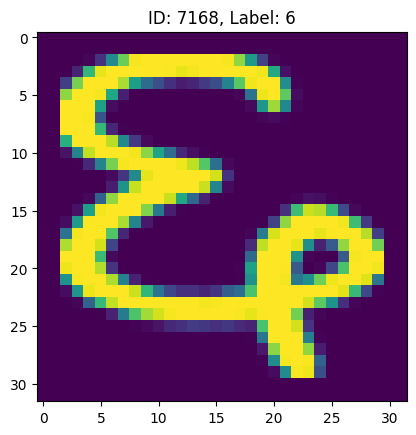

In [2]:
# view original image
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"ID: {sample_id}, Label: {sample_label}")
plt.show()

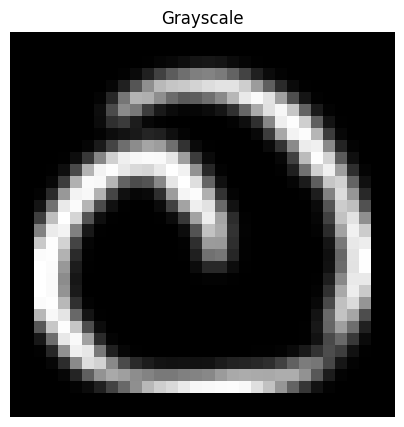

In [3]:
# convert to grayscale
# function from lab 3
def show_images(images, titles, cmap=None):
    n = len(images)
    plt.figure(figsize=(5*n, 5))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

# Pick one image from class 0
img_path = "train/train/0/103265.png"
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

show_images([gray], ["Grayscale"])

In [4]:
# train images to grayscale
# import pandas as pd
# import numpy as np

# train_df = pd.read_csv("train.csv")

# images = []
# labels = []

# for _, row in train_df.iterrows():
#     img_id = row["Id"]
#     label = row["Category"]
#     path = f"train/train/{label}/{img_id}.png"
    
#     img = cv2.imread(path)
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     images.append(gray)
#     labels.append(label)

# images = np.array(images)
# labels = np.array(labels)

# print(f"Loaded {len(images)} images, shape: {images.shape}")

In [5]:
# # save grayscale images locally
# from pathlib import Path

# output_dir = Path("train_gray")
# output_dir.mkdir(exist_ok=True)

# for _, row in train_df.iterrows():
#     img_id = row["Id"]
#     label = row["Category"]
#     path = f"train/train/{label}/{img_id}.png"
    
#     img = cv2.imread(path)
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     cv2.imwrite(str(output_dir / f"{img_id}.png"), gray)

# print("Done saving grayscale images")

In [6]:
# read in grayscale images
train_df = pd.read_csv("train.csv")

images = np.array([
    cv2.imread(f"train_gray/{row['Id']}.png", cv2.IMREAD_GRAYSCALE)
    for _, row in tqdm(train_df.iterrows(), total=len(train_df))
])
labels = train_df["Category"].values

print(f"Loaded {len(images)} images, shape: {images.shape}")

100%|██████████████████████████████████████████████████████████████████████████| 17000/17000 [00:04<00:00, 4134.18it/s]

Loaded 17000 images, shape: (17000, 32, 32)


In [7]:
# train val split:
from sklearn.model_selection import train_test_split
# Flatten images: (N, 32, 32) -> (N, 1024)
X = images.reshape(len(images), -1) / 255.0  # normalize to 0-1
y = labels

# reshuffle and split into train and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=75, stratify=y)

In [8]:
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

# ViT hyperparameters
patch_size = 2          # small patches = more detail (256 patches)
num_patches = (32 // patch_size) ** 2  # 256
projection_dim = 64
num_heads = 4
transformer_layers = 4
mlp_dim = 128

def mlp_block(x, dim):
    x = layers.Dense(dim, activation="relu")(x)
    x = layers.Dense(projection_dim)(x)
    return x

def transformer_block(x):
    # Self-attention
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim)(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.1)(x)
    # MLP
    mlp = mlp_block(x, mlp_dim)
    x = layers.Add()([x, mlp])
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.1)(x)
    return x

# Build ViT
inputs = keras.Input(shape=(1024,))  # flattened 32x32

# Split into patches
patches = layers.Reshape((num_patches, patch_size * patch_size))(inputs)

# Project patches
x = layers.Dense(projection_dim)(patches)

# Add positional embedding
positions = tf.range(start=0, limit=num_patches, delta=1)
pos_embed = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)(positions)
x = x + pos_embed

# Transformer blocks
for _ in range(transformer_layers):
    x = transformer_block(x)

# Classification head
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(10, activation="softmax")(x)

vit_model = keras.Model(inputs, outputs)

# Learning rate schedule
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=40 * len(X_train) // 32
)
vit_model.compile(
    optimizer=keras.optimizers.Adam(lr_schedule),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
vit_model.summary()

# Train
history_vit = vit_model.fit(
    X_train, y_train,
    epochs=40,
    validation_data=(X_val, y_val),
    verbose=1
)

print(f"ViT val_accuracy: {max(history_vit.history['val_accuracy']):.4f}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 1024)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape (Reshape)             │ (None, 256, 4)            │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 256, 64)           │             320 │ reshape[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 256, 64)           │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 256, 64)           │          66,368 │ add[0][0], add[0][0]       │
│ (MultiHeadAttention)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (None, 256, 64)           │               0 │ add[0][0],                 │
│                               │                           │                 │ multi_head_attention[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 256, 64)           │             128 │ add_1[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 256, 64)           │               0 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 256, 128)          │           8,320 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 256, 64)           │           8,256 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_2 (Add)                   │ (None, 256, 64)           │               0 │ dropout_1[0][0],           │
│                               │                           │                 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_1         │ (None, 256, 64)           │             128 │ add_2[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 256, 64)           │               0 │ layer_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention_1        │ (None, 256, 64)           │          66,368 │ dropout_2[0][0],           │
│ (MultiHeadAttention)          │                           │                 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 337,930 (1.29 MB)

 Trainable params: 337,930 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 197s 474ms/step - accuracy: 0.2139 - loss: 2.0817 - val_accuracy: 0.2998 - val_loss: 1.8705
Epoch 2/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 188s 472ms/step - accuracy: 0.3158 - loss: 1.8397 - val_accuracy: 0.3202 - val_loss: 1.8127
Epoch 3/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 188s 471ms/step - accuracy: 0.3689 - loss: 1.7171 - val_accuracy: 0.3849 - val_loss: 1.6368
Epoch 4/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 187s 470ms/step - accuracy: 0.4331 - loss: 1.5376 - val_accuracy: 0.4228 - val_loss: 1.5205
Epoch 5/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 188s 472ms/step - accuracy: 0.4941 - loss: 1.3984 - val_accuracy: 0.5405 - val_loss: 1.3303
Epoch 6/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 192s 482ms/step - accuracy: 0.5538 - loss: 1.2475 - val_accuracy: 0.6101 - val_loss: 1.0771
Epoch 7/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 191s 480ms/step - accuracy: 0.6090 - loss: 1.0973 - val_accuracy: 0.6061 - val_loss: 1.1024
Epoch 8/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 192s 481ms/step - accuracy: 0.6454 -

133/133 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step


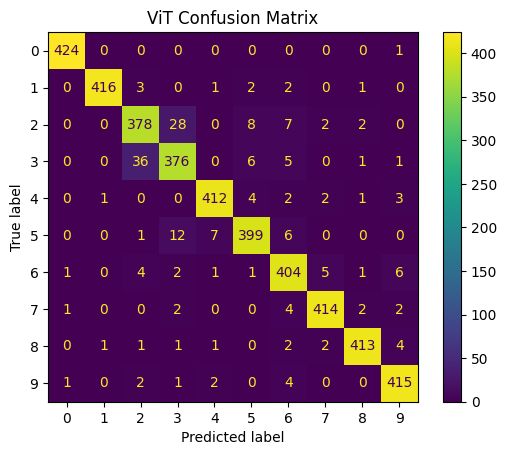

Most confused: true=3, predicted as=2 (36 errors)
Found 36 misclassified 3s predicted as 2


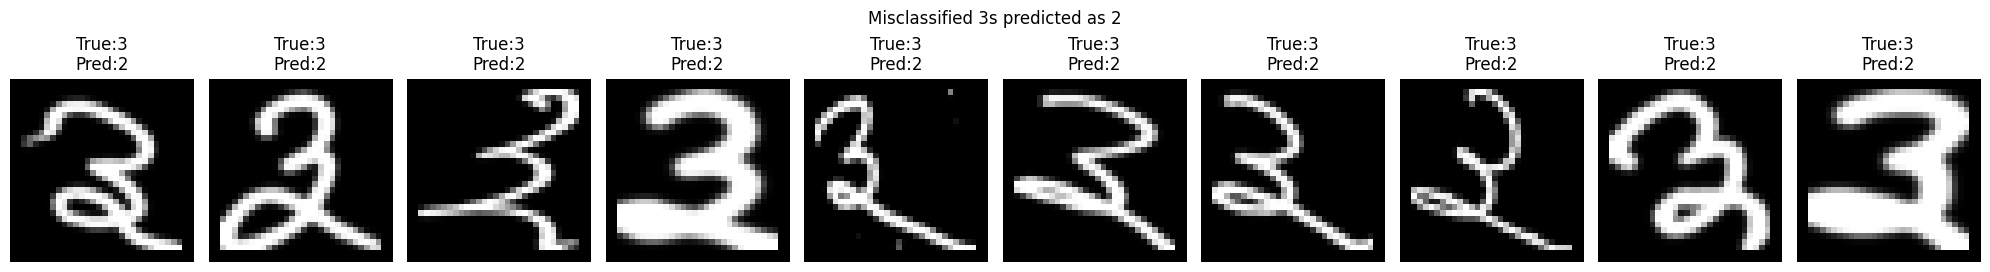

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# predictions
y_pred_vit = np.argmax(vit_model.predict(X_val), axis=1)

# confusion matrix
cm = confusion_matrix(y_val, y_pred_vit)
ConfusionMatrixDisplay(cm).plot()
plt.title("ViT Confusion Matrix")
plt.show()

# find the two most confused classes
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
most_confused = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
true_class, pred_class = most_confused
print(f"Most confused: true={true_class}, predicted as={pred_class} ({cm_no_diag[true_class, pred_class]} errors)")

# visualize misclassified images from that pair
mask = (y_val == true_class) & (y_pred_vit == pred_class)
misclassified_idx = np.where(mask)[0]
print(f"Found {len(misclassified_idx)} misclassified {true_class}s predicted as {pred_class}")

n = min(10, len(misclassified_idx))
plt.figure(figsize=(2*n, 3))
for i, idx in enumerate(misclassified_idx[:n]):
    img = X_val[idx].reshape(32, 32)
    plt.subplot(1, n, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True:{y_val[idx]}\nPred:{y_pred_vit[idx]}")
    plt.axis('off')
plt.suptitle(f"Misclassified {true_class}s predicted as {pred_class}")
plt.tight_layout()
plt.show()